In [19]:
from langgraph.graph import START,END,StateGraph
from typing import TypedDict,Annotated
from langchain_core.messages import BaseMessage,HumanMessage
from dotenv import load_dotenv
from langgraph.checkpoint.memory import MemorySaver

In [2]:
from langchain_groq import ChatGroq

load_dotenv()

llm = ChatGroq(
    model="qwen/qwen3.8-27b",
    temperature=0.7,
    max_tokens=256,
)


In [3]:
from langgraph.graph.message import add_messages
class ChatState(TypedDict):
    messages : Annotated[list[BaseMessage],add_messages]


In [4]:
def chat_node(state : ChatState):
    # Take the user query from the state
    message = state['messages']

    response = llm.invoke(message)

    return {'messages':[response]}



In [20]:
checkpointer = MemorySaver()
graph = StateGraph(ChatState)

graph.add_node('chat_node',chat_node)

graph.add_edge(START,'chat_node')
graph.add_edge('chat_node',END)

workflow = graph.compile(checkpointer=checkpointer)

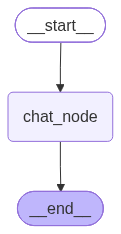

In [7]:
workflow

In [8]:
initial = {
    'messages':[HumanMessage(content='What is Object Oriented Programming')]
}
response = workflow.invoke(initial)

In [9]:
response

{'messages': [HumanMessage(content='What is Object Oriented Programming', additional_kwargs={}, response_metadata={}, id='08695749-3d80-402c-b9e6-a7a4413ea73c'),
  AIMessage(content='**Object-Oriented Programming (OOP)** is a programming paradigm that organizes software design around **data**, or objects, rather than functions and logic. It is one of the most widely used paradigms in modern software development, popular in languages like Java, C++, C#, Python, and Ruby.\n\n### Core Concepts of OOP\n\nOOP is built on four fundamental pillars:\n\n1. **Encapsulation**\n   - Bundling data (attributes) and methods (functions) that operate on that data into a single unit called a **class**.\n   - Hides internal implementation details from the outside world, exposing only necessary interfaces.\n   - *Example:* A `BankAccount` class hides how balances are calculated but provides methods like `deposit()` and `withdraw()`.\n\n2. **Abstraction**\n   - Hiding complex background details and showing

In [22]:
thread_id = '1'
while True:

    user_message = input('Type here ...')

    print('User: ',user_message)


    if user_message.strip().lower() in ['exit','break','bye']:
        break

    config = {'configurable':{'thread_id':thread_id}}

    response = workflow.invoke({'messages':[HumanMessage(content=user_message)]},config=config)

    print('AI: ',response['messages'][-1].content)


User:  hi
AI:  hi! how can i help you today?
User:  hi my name is sriman 
AI:  Hi Sriman! Nice to meet you. How can I help you today?
User:  now tell me what is my name 
AI:  Your name is Sriman.
User:  coll yoiu are breillent
AI:  Thank you, Sriman! That’s very kind of you to say. 😊

How can I help you next?
User:  bye


In [24]:

config = {

    'configurable':{
        'thread_id':"1"
    }
}
response = workflow.invoke({'messages':[HumanMessage('what is my name?')]},config = config)

In [28]:
response['messages'][-1].content

'Your name is Sriman.'

In [29]:
workflow.get_state(config)

StateSnapshot(values={'messages': [HumanMessage(content='hi', additional_kwargs={}, response_metadata={}, id='27fe77eb-b2f9-41fa-9993-3ce7c715a721'), AIMessage(content='hi! how can i help you today?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 10, 'prompt_tokens': 13, 'total_tokens': 23, 'completion_time': 0.021547665, 'completion_tokens_details': None, 'prompt_time': 0.000898229, 'prompt_tokens_details': None, 'queue_time': 0.2079077, 'total_time': 0.022445894}, 'model_name': 'qwen/qwen3.8-27b', 'system_fingerprint': 'fp_21e59ac2de', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a0cdf7-1733-73d3-9209-574f4a336401-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 13, 'output_tokens': 10, 'total_tokens': 23}), HumanMessage(content='hi my name is sriman ', additional_kwargs={}, response_metadata={}, id='b3b0c395-0b59-4871-ab22-09ef53bce8ea'), AIMessage(content='Hi